# trajguard — end-to-end pipeline walkthrough

A presentation-ready tour of **every stage and every runnable combination** in the
trajguard benchmark: bare maps → raw trajectories → cleaning → map matching →
representation views → splits → anonymization (with and without re-matching) →
synthetic generation → all four attack families → utility metrics → a full
orchestrated experiment → the risk report → the RN-LDP-Synth evidence sweep.

**How to use it**

- Run top to bottom (*Run → Run All Cells*). Everything is **offline by default**:
  it uses the committed test fixtures (a real slice of Beijing's OpenStreetMap and
  synthetic Geolife-format traces), so no dataset download or map build is needed.
- Every step is **deterministic** (fixed seeds) — the numbers you see are the
  numbers in the committed outputs.
- Stages that the design plans but the code does **not implement yet** are marked
  with ⚠️ and demonstrated as such, so the roadmap is visible next to the working
  parts.
- To run on **real data** instead, flip `USE_REAL_DATA = True` in the setup cell
  (requires the built `maps/beijing` network and the Geolife download —
  see `docs/RUNNING.md` §2). Fixture-specific sections (planted cleaning defects,
  fixture-scale caveats) keep using the committed fixtures either way.

Total runtime on the fixtures: a few minutes. Commands-and-troubleshooting
reference: `docs/RUNNING.md`.

## 1. Setup

Imports, paths, and the road network. The network is a **genuine slice of Beijing's
OpenStreetMap** (183 nodes / 388 edges around the Tsinghua campus) committed under
`tests/fixtures/maps/beijing_fixture` — the same code loads the full `maps/beijing`
build when `USE_REAL_DATA = True`.

In [1]:
import itertools
import json
import logging
import shutil
import tempfile
from dataclasses import replace
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer

from trajguard.datasets.cleaning import CleaningConfig, clean, haversine_m
from trajguard.datasets.geolife import GeolifeLoader
from trajguard.maps.osm import OSMMapSource

logging.disable(logging.WARNING)  # silence the matcher's linear-search notices
pd.set_option("display.width", 140)

ROOT = Path.cwd()
if not (ROOT / "tests" / "fixtures").exists():  # notebook usually runs from notebooks/
    ROOT = ROOT.parent
FIXTURES = ROOT / "tests" / "fixtures"
SEED = 42

USE_REAL_DATA = False  # True: use maps/beijing + data/raw/geolife (see docs/RUNNING.md §2)

if USE_REAL_DATA:
    NET = OSMMapSource("beijing", (116.20, 39.75, 116.55, 40.05), "EPSG:32650", ROOT / "maps").load()
    TRAJ_ROOT = ROOT / "data" / "raw" / "geolife"
else:
    NET = OSMMapSource(
        "beijing_fixture", (116.30, 39.98, 116.32, 39.995), "EPSG:32650", FIXTURES / "maps"
    ).load()
    TRAJ_ROOT = FIXTURES / "geolife_onroad"

TO_XY = Transformer.from_crs("EPSG:4326", NET.crs, always_xy=True)

def project(points):
    """(lat, lon, ...) tuples -> two arrays of projected x, y in metres."""
    xy = [TO_XY.transform(p[1], p[0]) for p in points]
    return np.array([p[0] for p in xy]), np.array([p[1] for p in xy])

def base_map(ax, edges=None, color="lightgray", lw=1.0):
    (edges if edges is not None else NET.edges).plot(ax=ax, color=color, linewidth=lw, zorder=1)
    ax.set_aspect("equal")

print(f"network: {NET.region} — {len(NET.nodes)} nodes, {len(NET.edges)} edges, {NET.crs}")
print(f"trajectory source: {TRAJ_ROOT.relative_to(ROOT)}")

network: beijing_fixture — 183 nodes, 388 edges, EPSG:32650
trajectory source: tests/fixtures/geolife_onroad


## 2. What is pluggable, what exists, what is planned

Everything in trajguard plugs into a **registry** keyed by `(kind, name)` — the
orchestrator addresses implementations by name from YAML. The first table lists
what is actually registered in this checkout; the second checks the components the
design document plans (§6/§7) against the registry live, so ⚠️ rows are guaranteed
up to date with the code.

Two footnotes the tables can't show: the two utility metrics
(`cell_js_divergence`, `length_dist_error`) are plain functions dispatched via a
dict, not registry classes; and of the four attacks only **reidentification** is
wired into YAML-driven orchestrator runs — the other three run through their
Python APIs, exactly as demonstrated in section 13.

In [2]:
import trajguard.experiments.builtins  # noqa: F401 — importing runs every @register
from trajguard.experiments.registry import _REGISTRY

implemented = pd.DataFrame(
    [(k, n, cls.__name__) for (k, n), cls in sorted(_REGISTRY.items())],
    columns=["kind", "registered name", "class"],
)
implemented

,kind,registered name,class
0,attack,membership_inference,MembershipInferenceAttack
1,attack,poi_inference,PoiInferenceAttack
2,attack,reconstruction,ReconstructionAttack
3,attack,reidentification,ReidentificationAttack
4,dataset,geolife,GeolifeLoader
5,generator,markov,MarkovGenerator
6,generator,rn_ldp_synth,RNLDPSynthGenerator
7,map_source,osm,OSMMapSource
8,matcher,leuven,LeuvenMapMatcher
9,mechanism,geo_indistinguishability,GeoIndistinguishability


In [3]:
PLANNED = [
    ("map_source", "osm", "OSM download / build / load (P1)"),
    ("dataset", "geolife", "Geolife .plt loader (P1)"),
    ("dataset", "tdrive", "T-Drive CSV loader — horizon B"),
    ("dataset", "porto", "Porto POLYLINE loader — horizon B"),
    ("matcher", "leuven", "HMM map matcher, pure Python (P2)"),
    ("matcher", "fmm", "Fast Map Matching (C++) — planned production matcher"),
    ("mechanism", "none", "identity baseline (P3)"),
    ("mechanism", "geo_indistinguishability", "planar Laplace noise (P5)"),
    ("mechanism", "spatial_rounding", "grid generalisation — design §7"),
    ("mechanism", "temporal_downsampling", "point thinning — design §7"),
    ("mechanism", "gaussian_noise", "naive spatial noise — design §7"),
    ("mechanism", "point_ldp", "randomized response over cells — design §7"),
    ("mechanism", "square_wave", "LDP for numeric distributions — design §7"),
    ("mechanism", "segment_perturbation", "network-aware perturbation — design §7"),
    ("mechanism", "k_anonymity_traj", "k-anonymity — design §7 / horizon B"),
    ("generator", "markov", "n-gram over road segments (P6)"),
    ("generator", "rn_ldp_synth", "RN-LDP-Synth v1 prototype (doctoral mechanism)"),
    ("generator", "dpt", "DPT central-DP synthesis — design §7"),
    ("generator", "adatrace", "AdaTrace central-DP synthesis — design §7"),
    ("generator", "diff_rntraj", "Diff-RNTraj diffusion — horizon B"),
    ("generator", "controltraj", "ControlTraj diffusion — horizon B"),
    ("attack", "reidentification", "linkage via known points + DTW (P4)"),
    ("attack", "membership_inference", "LiRA-lite shadow models (P6)"),
    ("attack", "reconstruction", "MAP inversion of known noise (P6)"),
    ("attack", "poi_inference", "home/work stay-point inference (P6.5)"),
    ("attack", "attribute_classifier", "full attribute inference — horizon B"),
    ("metric", "top_k_accuracy", "top-k reidentification accuracy (P4)"),
    ("metric", "linkage_rate", "correct-first-guess rate (P4)"),
]
matrix = pd.DataFrame(
    [
        (k, n, "\u2705 implemented" if (k, n) in _REGISTRY else "\u26a0\ufe0f not implemented", desc)
        for k, n, desc in PLANNED
    ],
    columns=["kind", "name", "status", "what it is"],
)
matrix

,kind,name,status,what it is
0,map_source,osm,✅ implemented,OSM download / build / load (P1)
1,dataset,geolife,✅ implemented,Geolife .plt loader (P1)
2,dataset,tdrive,⚠️ not implemented,T-Drive CSV loader — horizon B
3,dataset,porto,⚠️ not implemented,Porto POLYLINE loader — horizon B
4,matcher,leuven,✅ implemented,"HMM map matcher, pure Python (P2)"
5,matcher,fmm,⚠️ not implemented,Fast Map Matching (C++) — planned production m...
6,mechanism,none,✅ implemented,identity baseline (P3)
7,mechanism,geo_indistinguishability,✅ implemented,planar Laplace noise (P5)
8,mechanism,spatial_rounding,⚠️ not implemented,grid generalisation — design §7
9,mechanism,temporal_downsampling,⚠️ not implemented,point thinning — design §7


## 3. The bare road network

The foundation everything else sits on: nodes are intersections, edges are street
segments with real geometry, projected to metric coordinates (`EPSG:32650`, UTM
zone 50N) so distances read in metres.

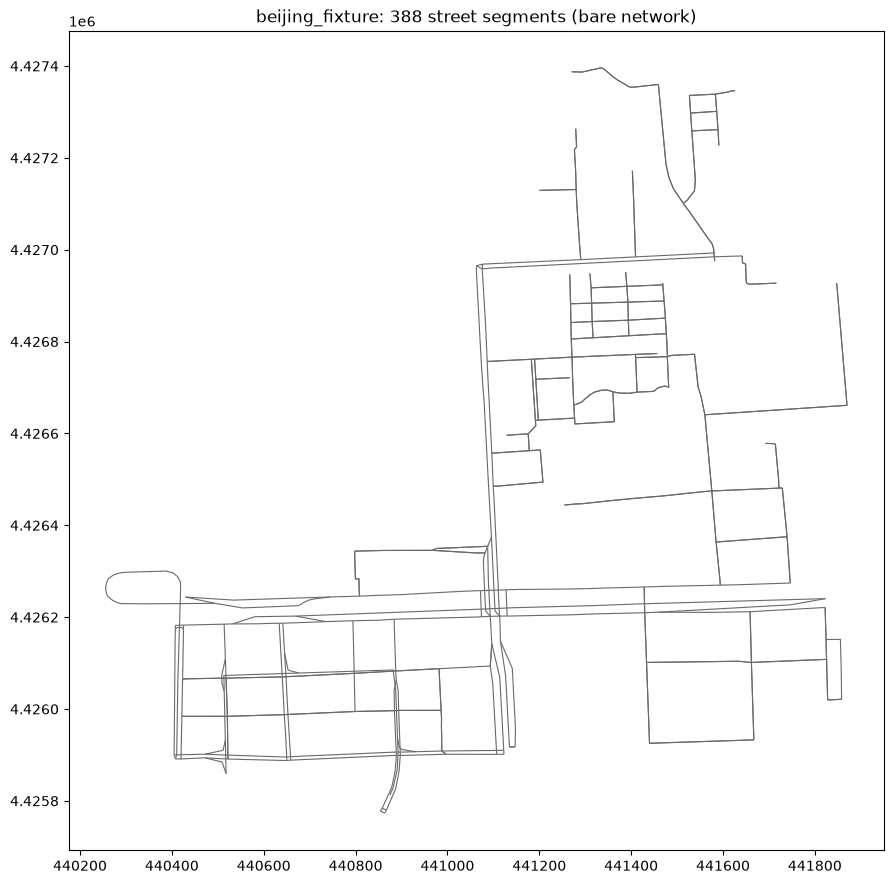

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
base_map(ax, color="dimgray", lw=0.8)
ax.set_title(f"{NET.region}: {len(NET.edges)} street segments (bare network)")
plt.tight_layout()

⚠️  maps/ljubljana not built — run: uv run python -m trajguard.maps.build config/maps.yaml --region ljubljana


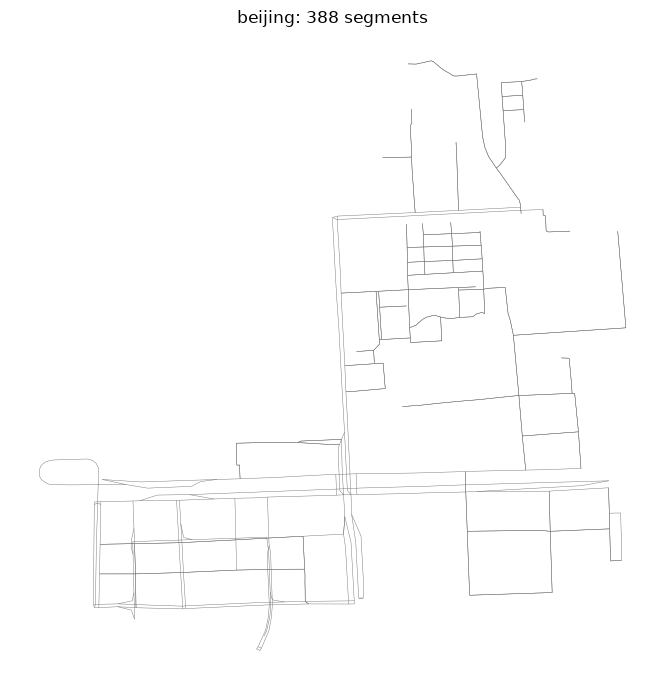

In [5]:
# Other built networks, when present on this machine (see docs/RUNNING.md §2.1).
for region, crs in [("beijing", "EPSG:32650"), ("ljubljana", "EPSG:3794")]:
    built = (ROOT / "maps" / region / "graph.graphml").exists()
    if not built:
        print(f"\u26a0\ufe0f  maps/{region} not built — run: "
              f"uv run python -m trajguard.maps.build config/maps.yaml --region {region}")
        continue
    other = OSMMapSource(region, (0, 0, 0, 0), crs, ROOT / "maps").load()
    fig, ax = plt.subplots(figsize=(7, 7))
    other.edges.plot(ax=ax, color="dimgray", linewidth=0.3)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"{region}: {len(other.edges)} segments")
    plt.tight_layout()

## 4. Raw trajectories — imported, not yet matched

`GeolifeLoader` parses Geolife-format `.plt` files into `RawTrajectory` records.
Here we import the road-following fixture traces plus one deliberate **off-road
random walk** (black, dashed) that ignores streets — it will be our negative
control throughout. The GPS points float loosely around the streets; nothing ties
them to the road graph yet.

In [6]:
loader = GeolifeLoader(TRAJ_ROOT)
raws = list(loader.iter_trajectories())
walk_raw = next(
    r for r in GeolifeLoader(FIXTURES / "geolife").iter_trajectories()
    if r.traj_id == "geolife/001/20081026103000"
)

pd.DataFrame(
    [
        {
            "traj_id": r.traj_id,
            "user": r.user_id,
            "points": r.n_points,
            "start (UTC)": datetime.fromtimestamp(r.start_t, timezone.utc).strftime("%Y-%m-%d %H:%M"),
            "source file": Path(r.source_file).name,
        }
        for r in raws
    ]
)

,traj_id,user,points,start (UTC),source file
0,geolife/005/20081201080000,005,29,2008-12-01 08:00,20081201080000.plt
1,geolife/005/20081202080000,005,117,2008-12-02 08:00,20081202080000.plt
2,geolife/005/20081203080000,005,95,2008-12-03 08:00,20081203080000.plt
3,geolife/005/20081204080000,005,27,2008-12-04 08:00,20081204080000.plt
4,geolife/006/20081205080000,006,29,2008-12-05 08:00,20081205080000.plt
5,geolife/006/20081206080000,006,70,2008-12-06 08:00,20081206080000.plt
6,geolife/006/20081207080000,006,103,2008-12-07 08:00,20081207080000.plt
7,geolife/006/20081208080000,006,34,2008-12-08 08:00,20081208080000.plt


first three points of geolife/005/20081201080000 -> ((39.981562, 116.31073, 1228118400.0), (39.981747, 116.310744, 1228118405.0), (39.981986, 116.310664, 1228118410.0))


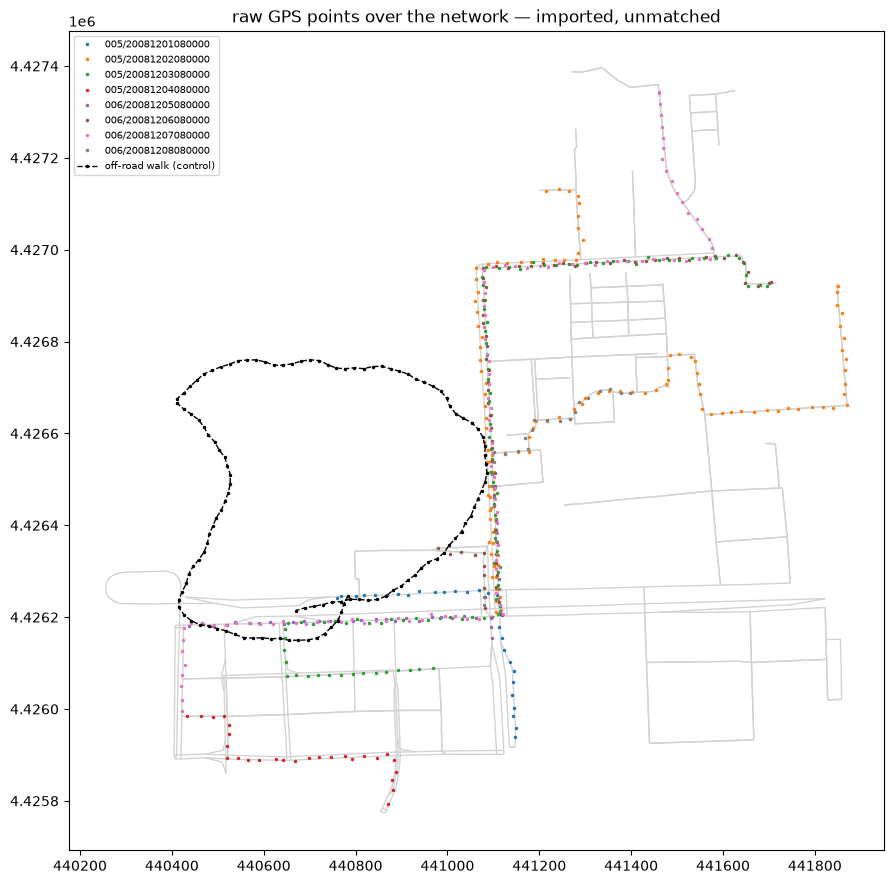

In [7]:
print("first three points of", raws[0].traj_id, "->", raws[0].points[:3])

fig, ax = plt.subplots(figsize=(9, 9))
base_map(ax)
cmap = plt.colormaps["tab10"]
for i, r in enumerate(raws):
    xs, ys = project(r.points)
    ax.plot(xs, ys, ".", ms=3, color=cmap(i % 10), label=r.traj_id.split("/", 1)[1])
wx, wy = project(walk_raw.points)
ax.plot(wx, wy, "k--.", lw=1, ms=3, label="off-road walk (control)")
ax.set_title("raw GPS points over the network — imported, unmatched")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()

## 5. Cleaning

`clean()` drops speed-impossible points, thins to the resampling interval, and
rejects whole trajectories that end up too short. The committed defect fixture set
has **planted flaws** (documented in `tests/fixtures/geolife/README.md`), so we can
watch the cleaner catch each one: a trajectory with three 4 000 km/h teleport
spikes keeps its shape but loses the spikes; one with 5 points and one only ~70 m
long are rejected outright (`clean()` returns `None`).

In [8]:
EXPECTED_DEFECTS = {
    "geolife/000/20081023025304": "none (parsing reference)",
    "geolife/002/20081101020000": "3 planted speed spikes",
    "geolife/004/20081104010000": "only 5 points",
    "geolife/004/20081105010000": "~70 m total length",
}
cfg = CleaningConfig()  # max 200 km/h, >=20 points, >=500 m, 5 s resampling
defect_raws = list(GeolifeLoader(FIXTURES / "geolife").iter_trajectories())

rows = []
for r in defect_raws:
    c = clean(r, cfg)
    rows.append(
        {
            "traj_id": r.traj_id,
            "planted defect": EXPECTED_DEFECTS.get(r.traj_id, "—"),
            "points in": r.n_points,
            "points out": len(c.points) if c else 0,
            "flags": ", ".join(c.cleaning_flags) if c else "",
            "verdict": "kept" if c else "REJECTED",
        }
    )
pd.DataFrame(rows)

,traj_id,planted defect,points in,points out,flags,verdict
0,geolife/000/20081023025304,none (parsing reference),100,34,"speed_outliers_dropped:0, resampled:5s",kept
1,geolife/000/20081024081500,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
2,geolife/000/20081025081500,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
3,geolife/000/20081026081500,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
4,geolife/001/20081026103000,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
5,geolife/001/20081027103000,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
6,geolife/001/20081028103000,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
7,geolife/001/20081029103000,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept
8,geolife/002/20081101020000,3 planted speed spikes,100,33,"speed_outliers_dropped:3, resampled:5s",kept
9,geolife/002/20081102144500,—,120,40,"speed_outliers_dropped:0, resampled:5s",kept


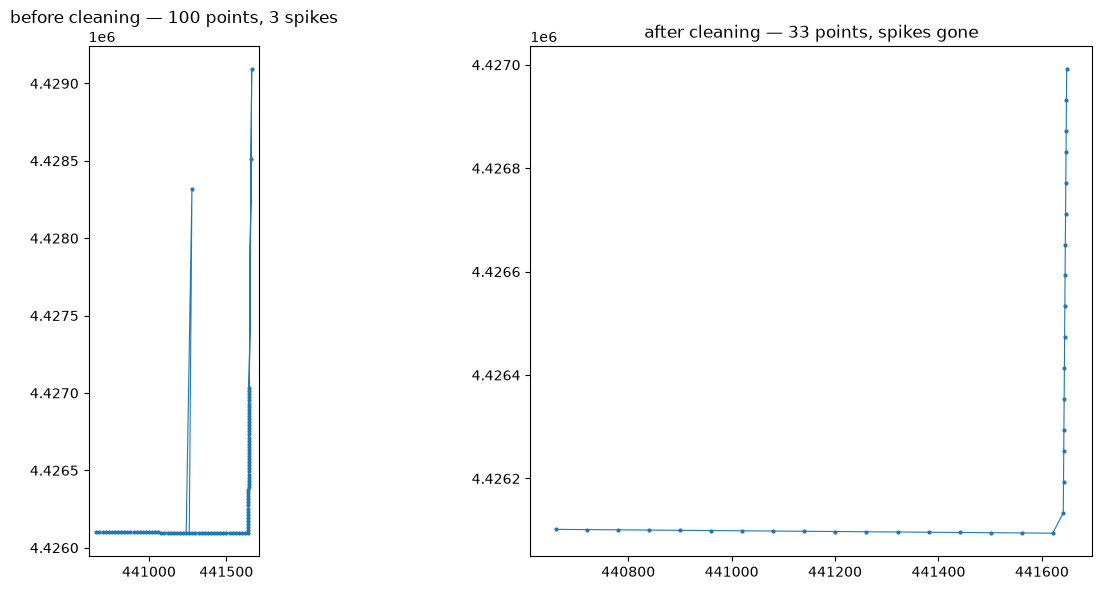

In [9]:
spiky = next(r for r in defect_raws if r.traj_id == "geolife/002/20081101020000")
spiky_clean = clean(spiky, cfg)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pts, title in [
    (axes[0], spiky.points, f"before cleaning — {spiky.n_points} points, 3 spikes"),
    (axes[1], spiky_clean.points, f"after cleaning — {len(spiky_clean.points)} points, spikes gone"),
]:
    xs, ys = project(pts)
    ax.plot(xs, ys, "-o", ms=2, lw=0.8, color="tab:blue")
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()

In [10]:
# Clean the road-following set (plus the off-road control) for the pipeline below.
cleaned = [c for r in raws if (c := clean(r, cfg))]
walk_clean = clean(walk_raw, cfg)
clean_by_id = {c.traj_id: c for c in cleaned}
print(f"road-following: {len(cleaned)}/{len(raws)} survive cleaning; "
      f"off-road control survives too ({len(walk_clean.points)} points) — "
      "cleaning checks physics, not geography. Map matching is what catches it next.")

road-following: 8/8 survive cleaning; off-road control survives too (40 points) — cleaning checks physics, not geography. Map matching is what catches it next.


## 6. Map matching — snapping GPS onto the road graph

`LeuvenMapMatcher` (a hidden-Markov-model matcher) turns each cleaned GPS sequence
into a path of road-segment ids (`edge_seq`) plus a `match_score`. Trajectories
under the 0.6 score threshold are dropped — which is exactly what happens to the
off-road control, while every genuine trace scores ≈0.9.

⚠️ The design names `fmm` (a faster C++ matcher) as the eventual production
matcher; it is **not implemented yet** — `leuven` is the only registered matcher.

In [11]:
from trajguard.matching.base import match_many
from trajguard.matching.leuven import LeuvenMapMatcher

matcher = LeuvenMapMatcher()  # radius 50 m, gps error 20 m, 8 candidates

rows, results = [], {}
for traj in [*cleaned, walk_clean]:
    m = matcher.match(traj, NET)
    q = matcher.quality(m)
    results[traj.traj_id] = m
    rows.append(
        {
            "traj_id": traj.traj_id,
            "points": len(traj.points),
            "edges": int(q["n_edges"]),
            "mean offset (m)": round(q["mean_offset_m"], 1),
            "match_score": round(m.match_score, 3),
            "kept @ 0.6": m.match_score >= 0.6,
        }
    )
matched, n_dropped = match_many(matcher, [*cleaned, walk_clean], NET, min_match_score=0.6)
matched_by_id = {m.traj_id: m for m in matched}
print(f"kept {len(matched)}, dropped {n_dropped} (the off-road control)")
pd.DataFrame(rows)

kept 8, dropped 1 (the off-road control)


,traj_id,points,edges,mean offset (m),match_score,kept @ 0.6
0,geolife/005/20081201080000,29,9,4.9,0.886,True
1,geolife/005/20081202080000,117,22,5.3,0.877,True
2,geolife/005/20081203080000,95,19,3.3,0.921,True
3,geolife/005/20081204080000,27,7,3.3,0.921,True
4,geolife/006/20081205080000,29,10,2.3,0.943,True
5,geolife/006/20081206080000,70,13,3.8,0.909,True
6,geolife/006/20081207080000,103,22,3.9,0.908,True
7,geolife/006/20081208080000,34,13,2.9,0.930,True
8,geolife/001/20081026103000,40,1,39.4,0.009,False


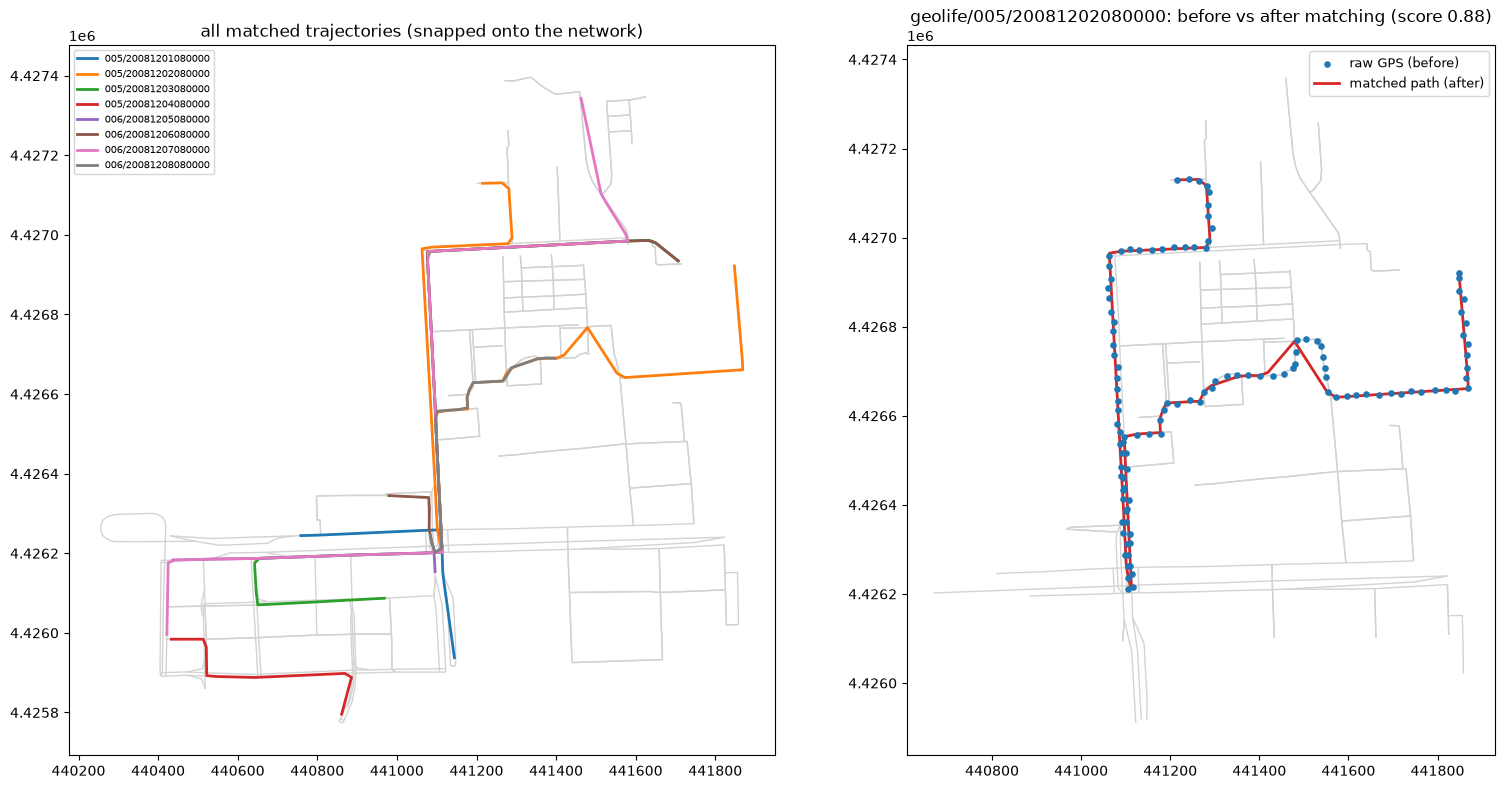

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

base_map(axes[0])
cmap = plt.colormaps["tab10"]
for i, m in enumerate(matched):
    xs = [p[0] for p in m.matched_points]
    ys = [p[1] for p in m.matched_points]
    axes[0].plot(xs, ys, "-", color=cmap(i % 10), lw=2, label=m.traj_id.split("/", 1)[1])
axes[0].set_title("all matched trajectories (snapped onto the network)")
axes[0].legend(fontsize=7, loc="upper left")

demo = matched_by_id[cleaned[1].traj_id]
xs = [p[0] for p in demo.matched_points]
ys = [p[1] for p in demo.matched_points]
pad = 80
crop = NET.edges.cx[min(xs) - pad : max(xs) + pad, min(ys) - pad : max(ys) + pad]
base_map(axes[1], edges=crop)
gx, gy = project(clean_by_id[demo.traj_id].points)
axes[1].scatter(gx, gy, s=14, color="tab:blue", zorder=3, label="raw GPS (before)")
axes[1].plot(xs, ys, "-", color="tab:red", lw=2, zorder=2, label="matched path (after)")
axes[1].set_title(f"{demo.traj_id}: before vs after matching (score {demo.match_score:.2f})")
axes[1].legend(fontsize=9)
plt.tight_layout()

## 7. Representation views — one trajectory, many shapes

Attacks and mechanisms don't consume trajectories directly; they consume **views**:
GPS points, road-segment ids, or spatial grid cells. Two further views the design
plans (graph path, POI visits) are deliberate ⚠️ not-implemented hooks — calling
them raises `NotImplementedError`, shown live below.

as_gps()      -> ((39.992289, 116.311413, 1228204800.0), (39.992317, 116.311732, 1228204805.0)) …
as_segments() -> (341, 117, 114, 0, 2, 6, 16, 227, 14, 17, 358, 354, 352, 349, 374, 283, 271, 286, 277, 107, 95, 98)
as_cells()    -> (52, 52, 52, 52, 52, 52, 52, 52, 52, 44, 44, 44, 44, 44, 44, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 35, 35, 35, 35, 35, 35, 35, 35, 27, 27, 27, 27, 27, 27, 27, 27, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 27, 27, 27, 27, 27, 27, 27, 27, 27, 28, 28, 36, 36, 36, 36, 36, 36, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 47, 47, 47, 47, 47, 47, 47)
⚠️  as_graph_path(): NotImplementedError — graph-path view is a horizon-B hook (design §2.2)
⚠️  as_poi_visits(): NotImplementedError — POI view is a horizon-B hook (design §2.2)


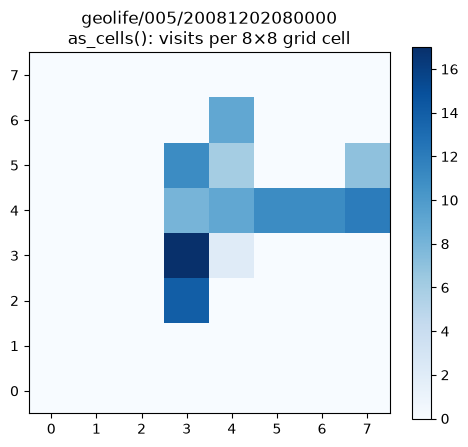

In [13]:
from trajguard.representation import Grid, TrajectoryView

view = TrajectoryView(clean=clean_by_id[demo.traj_id], matched=demo)
lats = NET.nodes["lat"].astype(float)
lons = NET.nodes["lon"].astype(float)
GRID = Grid(bbox=(lons.min(), lats.min(), lons.max(), lats.max()), n_rows=8, n_cols=8)

print("as_gps()      ->", view.as_gps()[:2], "…")
print("as_segments() ->", view.as_segments())
print("as_cells()    ->", view.as_cells(GRID))
for hook, arg in [("as_graph_path", ()), ("as_poi_visits", (None,))]:
    try:
        getattr(view, hook)(*arg)
    except NotImplementedError as err:
        print(f"\u26a0\ufe0f  {hook}(): NotImplementedError — {err}")

counts = np.zeros(GRID.n_cells)
for c in view.as_cells(GRID):
    counts[c] += 1
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(counts.reshape(GRID.n_rows, GRID.n_cols), origin="lower", cmap="Blues")
ax.set_title(f"{view.traj_id}\nas_cells(): visits per 8×8 grid cell")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

## 8. The one-time user split

Before any attack, users are split **once** into train / test / shadow / attack
groups (whole users, never individual trips — otherwise a membership attack could
cheat by seeing a user's other trips at training time). The split is deterministic
in the seed. Here we pool the users from both fixture sets to make the four-way
split visible.

In [14]:
from trajguard.datasets.split import split_by_user

pool = [c for r in defect_raws if (c := clean(r, cfg))] + cleaned
fractions = {"train": 0.5, "test": 0.2, "shadow": 0.2, "attack": 0.1}
split_once = split_by_user(pool, fractions, seed=SEED)
split_again = split_by_user(pool, fractions, seed=SEED)
assert [t.split for t in split_once] == [t.split for t in split_again]
print(f"deterministic: same seed -> identical split of {len({t.user_id for t in pool})} users\n")

pd.DataFrame(
    [
        {"split": s, "users": ", ".join(sorted({t.user_id for t in split_once if t.split == s})),
         "trajectories": sum(t.split == s for t in split_once)}
        for s in ["train", "test", "shadow", "attack"]
    ]
)

deterministic: same seed -> identical split of 7 users



,split,users,trajectories
0,train,"002, 003, 004, 006",14
1,test,001,4
2,shadow,005,4
3,attack,000,4


## 9. Anonymization **without** map matching

`GeoIndistinguishability` adds planar Laplace noise to every GPS point — the
formal guarantee is that locations within a radius stay statistically
indistinguishable. `epsilon` is the privacy level **per 100 m**; the mean
displacement is `2 × 100 / ε` metres, so the three standard arms mean:

| ε | mean displacement |
|---|---|
| 0.1 | ≈ 2 000 m (release visually destroyed) |
| 1.0 | ≈ 200 m |
| 10.0 | ≈ 20 m (mild) |

The baseline `NoProtection` mechanism passes points through unchanged (verified
below). ⚠️ The remaining mechanisms in the design's §7 table are not implemented —
the list is generated live from the registry.

In [15]:
from trajguard.privacy.geoind import GeoIndistinguishability
from trajguard.privacy.none import NoProtection

subject = clean_by_id[demo.traj_id]
subject_view = TrajectoryView(clean=subject)

assert NoProtection().apply(subject_view).payload == subject_view.as_gps()
print("NoProtection: payload identical to the original GPS view \u2705\n")

EPSILONS = [0.1, 1.0, 10.0]
noisy_payloads, rows = {}, []
for eps in EPSILONS:
    mech = GeoIndistinguishability(epsilon=eps, unit_m=100.0, seed=SEED)
    payload = mech.apply(subject_view).payload
    noisy_payloads[eps] = payload
    disp = [haversine_m(a[0], a[1], b[0], b[1]) for a, b in zip(subject.points, payload)]
    rows.append({"epsilon": eps, "theoretical mean displacement (m)": 200.0 / eps,
                 "empirical mean (m)": round(float(np.mean(disp)), 1),
                 "spent budget (eps × points)": mech.spent_budget()})
pd.DataFrame(rows)

NoProtection: payload identical to the original GPS view ✅



,epsilon,theoretical mean displacement (m),empirical mean (m),spent budget (eps × points)
0,0.1,2000.0,1881.2,11.7
1,1.0,200.0,188.1,117.0
2,10.0,20.0,18.8,1170.0


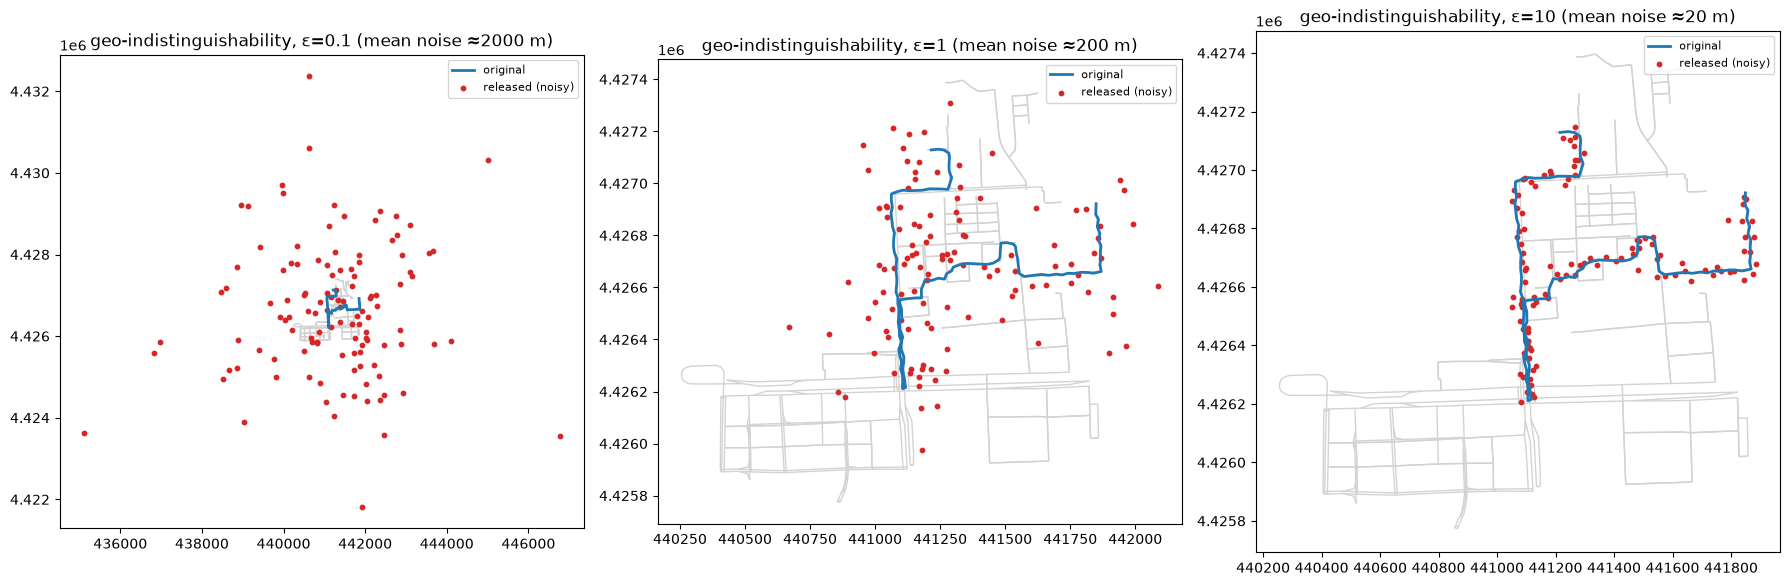

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rx, ry = project(subject.points)
for ax, eps in zip(axes, EPSILONS):
    base_map(ax)
    nx_, ny_ = project(noisy_payloads[eps])
    ax.plot(rx, ry, "-", color="tab:blue", lw=2, zorder=3, label="original")
    ax.scatter(nx_, ny_, s=10, color="tab:red", zorder=2, label="released (noisy)")
    ax.set_title(f"geo-indistinguishability, \u03b5={eps:g} (mean noise \u2248{200 / eps:.0f} m)")
    ax.legend(fontsize=8)
plt.tight_layout()

In [17]:
missing = matrix[(matrix["kind"] == "mechanism") & matrix["status"].str.contains("not")]
print("\u26a0\ufe0f  privacy mechanisms planned in design §7 but NOT implemented yet:")
for _, r in missing.iterrows():
    print(f"   - {r['name']}: {r['what it is']}")

⚠️  privacy mechanisms planned in design §7 but NOT implemented yet:
   - spatial_rounding: grid generalisation — design §7
   - temporal_downsampling: point thinning — design §7
   - gaussian_noise: naive spatial noise — design §7
   - point_ldp: randomized response over cells — design §7
   - square_wave: LDP for numeric distributions — design §7
   - segment_perturbation: network-aware perturbation — design §7
   - k_anonymity_traj: k-anonymity — design §7 / horizon B


## 10. Local-differential-privacy building blocks (GRR / OUE)

RN-LDP-Synth is built on classic LDP **frequency oracles**: each device reports a
randomized version of its value; the server debiases the aggregate and never sees
any true value. Generalized Randomized Response (GRR) randomizes the category
itself; Optimized Unary Encoding (OUE) randomizes a one-hot bit vector. Watch the
estimate track the true distribution as ε grows.

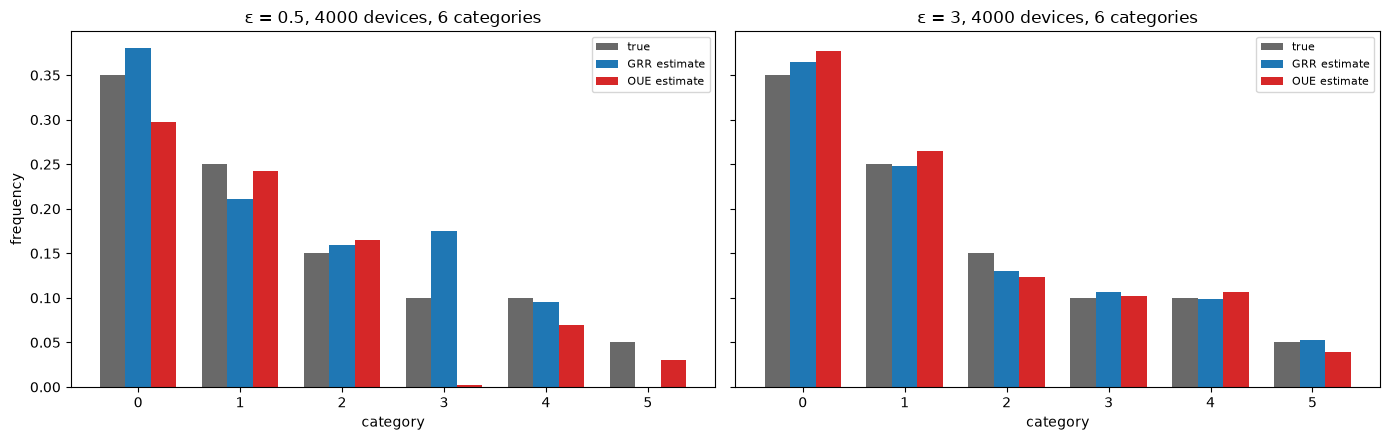

In [18]:
from trajguard.privacy.ldp import grr_estimate, grr_perturb, oue_estimate, oue_perturb

K, N = 6, 4000
true_p = np.array([0.35, 0.25, 0.15, 0.10, 0.10, 0.05])
rng = np.random.default_rng(SEED)
values = rng.choice(K, size=N, p=true_p)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, eps in zip(axes, [0.5, 3.0]):
    counts, bits = np.zeros(K), np.zeros(K)
    for v in values:
        counts[grr_perturb(int(v), K, eps, rng)] += 1
        bits += oue_perturb(int(v), K, eps, rng)
    grr_est = grr_estimate(counts, N, eps) / N
    oue_est = oue_estimate(bits, N, eps) / N
    x = np.arange(K)
    ax.bar(x - 0.25, true_p, 0.25, label="true", color="dimgray")
    ax.bar(x, grr_est, 0.25, label="GRR estimate", color="tab:blue")
    ax.bar(x + 0.25, oue_est, 0.25, label="OUE estimate", color="tab:red")
    ax.set_title(f"\u03b5 = {eps:g}, {N} devices, {K} categories")
    ax.set_xlabel("category")
    ax.legend(fontsize=8)
axes[0].set_ylabel("frequency")
plt.tight_layout()

## 11. Anonymization **with** re-matching (the attacker's view)

A released noisy trajectory can be snapped back onto roads by anyone with the
public map — this is exactly what the orchestrator does when building the
"protected" attack arm, so we reuse its own functions (`_noisy_clean` +
`match_many`). Strong noise destroys so much structure that trajectories fail
re-matching entirely: **"protection by destroying the release"** — the survivor
counts below are the same numbers `run.json` records as `n_rematch_dropped`.

In [19]:
from trajguard.experiments.orchestrator import _noisy_clean

ARMS = [
    ("\u03b5=0.1 (noise \u22482 km)", GeoIndistinguishability(0.1, 100.0, seed=SEED)),
    ("\u03b5=1.0 (noise \u2248200 m)", GeoIndistinguishability(1.0, 100.0, seed=SEED)),
    ("\u03b5=10.0 (noise \u224820 m)", GeoIndistinguishability(10.0, 100.0, seed=SEED)),
    ("\u03b5=10.0, unit 25 m (noise \u22485 m)", GeoIndistinguishability(10.0, 25.0, seed=SEED)),
]
protected_pools, noisy_releases, rows = {}, {}, []
for label, mech in ARMS:
    noisy = [
        _noisy_clean(clean_by_id[m.traj_id], mech.apply(
            TrajectoryView(clean=clean_by_id[m.traj_id], matched=m)).payload)
        for m in matched
    ]
    kept, dropped = match_many(matcher, noisy, NET, min_match_score=0.6)
    protected_pools[label], noisy_releases[label] = kept, noisy
    rows.append({"arm": label, "released": len(noisy), "re-matched (survive)": len(kept),
                 "n_rematch_dropped": dropped})
pd.DataFrame(rows)

,arm,released,re-matched (survive),n_rematch_dropped
0,ε=0.1 (noise ≈2 km),8,0,8
1,ε=1.0 (noise ≈200 m),8,0,8
2,ε=10.0 (noise ≈20 m),8,4,4
3,"ε=10.0, unit 25 m (noise ≈5 m)",8,8,0


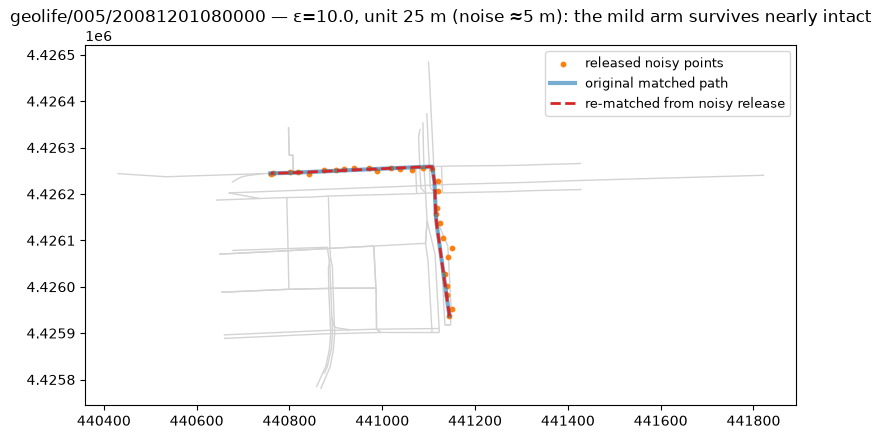

In [20]:
mild = ARMS[-1][0]
survivor = protected_pools[mild][0]
original = matched_by_id[survivor.traj_id]
noisy_pts = next(t for t in noisy_releases[mild] if t.traj_id == survivor.traj_id).points

fig, ax = plt.subplots(figsize=(8, 8))
ox = [p[0] for p in original.matched_points]; oy = [p[1] for p in original.matched_points]
sx = [p[0] for p in survivor.matched_points]; sy = [p[1] for p in survivor.matched_points]
pad = 80
base_map(ax, edges=NET.edges.cx[min(ox) - pad : max(ox) + pad, min(oy) - pad : max(oy) + pad])
nx_, ny_ = project(noisy_pts)
ax.scatter(nx_, ny_, s=10, color="tab:orange", zorder=2, label="released noisy points")
ax.plot(ox, oy, "-", color="tab:blue", lw=3, alpha=0.6, zorder=3, label="original matched path")
ax.plot(sx, sy, "--", color="tab:red", lw=2, zorder=4, label="re-matched from noisy release")
ax.set_title(f"{survivor.traj_id} — {mild}: the mild arm survives nearly intact")
ax.legend(fontsize=9)
plt.tight_layout()

## 12. Synthetic trajectory generation

Instead of perturbing real trips, a generator learns movement patterns and emits
**new, artificial trips**. Two generators are implemented:

- **Markov** (`markov`): an n-gram model over road-segment sequences — the simple,
  non-private baseline.
- **RN-LDP-Synth** (`rn_ldp_synth`): the doctoral v1 prototype. Each device sends
  only LDP-randomized reports (the GRR/OUE primitives from section 10) about its
  matched trip; the server reconstructs zone-level statistics and random-walks the
  road network. Design: `docs/RN_LDP_SYNTH_DESIGN.md`.

⚠️ Not implemented: the design's central-DP generators (DPT, AdaTrace) and the
horizon-B diffusion models (Diff-RNTraj, ControlTraj). With only 8 training
trajectories this is a **shape demo**, not an evaluation — section 17 runs the
proper (still fixture-scale) evidence sweep.

RN-LDP-Synth per-device budget: ε=2, split over stages (start/end/length/transitions): (0.3, 0.3, 0.4, 1.0)


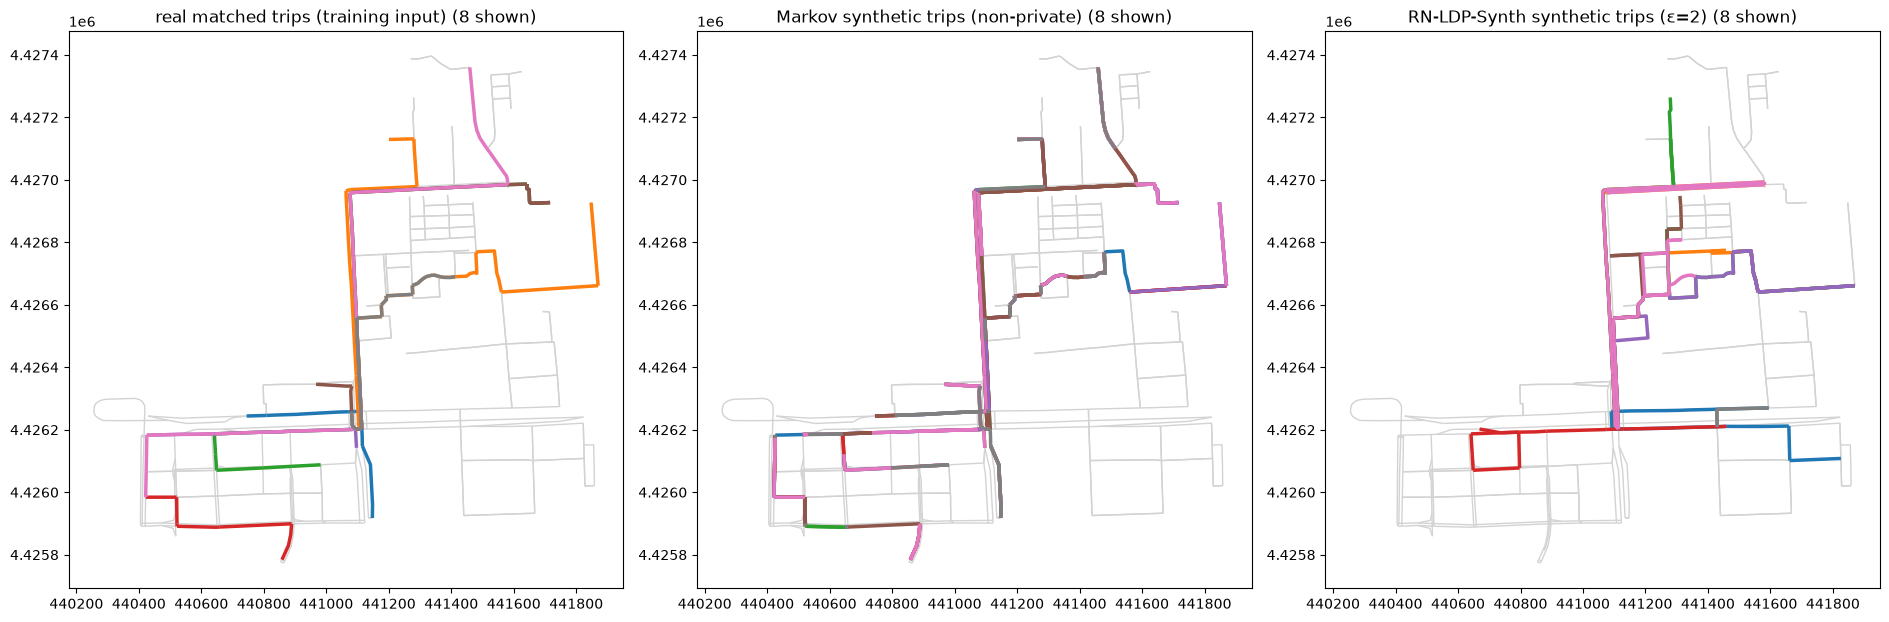

In [21]:
from trajguard.synthesis.markov import MarkovGenerator
from trajguard.synthesis.rn_ldp_synth import RNLDPSynthGenerator

train_views = [TrajectoryView(clean=clean_by_id[m.traj_id], matched=m) for m in matched]
EDGE_LOOKUP = NET.edges.set_index("edge_id", drop=False)

def plot_walks(ax, seqs, title):
    base_map(ax)
    cmap = plt.colormaps["tab10"]
    n = 0
    for i, seq in enumerate(seqs):
        if not seq:
            continue
        EDGE_LOOKUP.loc[list(seq)].plot(ax=ax, color=cmap(i % 10), linewidth=2.5, zorder=2)
        n += 1
    ax.set_title(f"{title} ({n} shown)")

markov = MarkovGenerator(order=1)
markov.fit(train_views)
syn_markov = markov.generate(8, seed=7)

rnldp = RNLDPSynthGenerator(NET, epsilon=2.0, n_rows=10, n_cols=10, l_max=12, seed=11)
rnldp.fit(train_views)
syn_rnldp = rnldp.generate(8, seed=SEED)
print(f"RN-LDP-Synth per-device budget: \u03b5={rnldp.spent_budget():g}, "
      f"split over stages (start/end/length/transitions): "
      f"{tuple(round(e, 2) for e in rnldp.stage_epsilons)}")

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
plot_walks(axes[0], [m.edge_seq for m in matched], "real matched trips (training input)")
plot_walks(axes[1], [s.payload for s in syn_markov], "Markov synthetic trips (non-private)")
plot_walks(axes[2], [s.payload for s in syn_rnldp], "RN-LDP-Synth synthetic trips (\u03b5=2)")
plt.tight_layout()

## 13. The four attack families

Each attack answers a different privacy question. Only **reidentification** is
wired into YAML/orchestrator runs so far; the other three run against their Python
APIs (which is how their tests drive them too).

| attack | question it asks | works on |
|---|---|---|
| reidentification | "which user does this trace belong to?" | raw, protected |
| membership inference | "was this trip in the generator's training data?" | synthetic |
| reconstruction | "what were the true locations behind this noise?" | protected |
| POI inference | "where does this user live and work?" | protected, synthetic |

### 13a. Reidentification — linkage by known points

The attacker knows `k` points of a target's trip and searches the released pool
for the closest trajectory (dynamic-time-warping distance). On the raw pool the
attack is nearly perfect; on the protected arm it degrades with the noise.
**Fixture caveat:** with only 2 users, a top-5 list trivially contains the right
user — the *relative* raw-vs-protected drop is the meaningful part.

In [22]:
from trajguard.attacks.base import BackgroundKnowledge
from trajguard.attacks.reidentification import ReidentificationAttack
from trajguard.evaluation.metrics import LinkageRate, TopKAccuracy, evaluate

def reid_metrics(gallery, aux, label, k=4):
    attack = ReidentificationAttack()
    attack.configure(BackgroundKnowledge(known_points=k, seed=SEED))
    result = attack.run(gallery, aux)
    values = evaluate(result, [TopKAccuracy(1), TopKAccuracy(5), LinkageRate()],
                      n_bootstrap=200, ci=0.95, seed=1)
    return [{"arm": label, "metric": v.name, "value": round(v.value, 3),
             "95% CI": f"[{v.ci_low:.2f}, {v.ci_high:.2f}]"} for v in values]

rows = reid_metrics(matched, None, "raw (unprotected)")
rows += reid_metrics(protected_pools[mild], matched, f"protected: {mild}")
rows += reid_metrics(protected_pools["\u03b5=1.0 (noise \u2248200 m)"], matched,
                     "protected: \u03b5=1.0 (0 survivors \u2014 nothing left to link)")
pd.DataFrame(rows)

,arm,metric,value,95% CI
0,raw (unprotected),top1_acc,0.25,"[0.00, 0.50]"
1,raw (unprotected),top5_acc,1.00,"[1.00, 1.00]"
2,raw (unprotected),linkage_rate,0.25,"[0.00, 0.50]"
3,"protected: ε=10.0, unit 25 m (noise ≈5 m)",top1_acc,0.25,"[0.00, 0.50]"
4,"protected: ε=10.0, unit 25 m (noise ≈5 m)",top5_acc,1.00,"[1.00, 1.00]"
5,"protected: ε=10.0, unit 25 m (noise ≈5 m)",linkage_rate,0.25,"[0.00, 0.50]"
6,protected: ε=1.0 (0 survivors — nothing left t...,top1_acc,0.00,"[0.00, 0.00]"
7,protected: ε=1.0 (0 survivors — nothing left t...,top5_acc,0.00,"[0.00, 0.00]"
8,protected: ε=1.0 (0 survivors — nothing left t...,linkage_rate,0.00,"[0.00, 0.00]"


### 13b. Membership inference — LiRA-lite with shadow models

Did a specific trip help train the generator? The attacker trains `n` *shadow*
generators on random subsets of a population and scores each candidate by how much
more likely the real generator finds it than the shadows do (a likelihood-ratio
test). AUC 0.5 = the attacker is guessing; 1.0 = training members are fully
exposed. We attack the non-private Markov generator and RN-LDP-Synth on the same
population. (At 24 candidates, TPR at 0.1% false positives is meaningless — we
report the 1% and 10% operating points, as the evidence sweep does.)

In [23]:
from trajguard.attacks.membership import MembershipInferenceAttack, membership_report
from trajguard.experiments.rnldp_eval import seed_population

population = seed_population(NET, 24, 3, seed=20260706)
seqs = [v.as_segments() for v in population]
members = list(range(12))
candidates = [(i, i in set(members)) for i in range(len(seqs))]

def mia_against(fit_generator, label):
    attack = MembershipInferenceAttack(n_shadow=8)
    attack.configure(BackgroundKnowledge(known_points=0, seed=1))
    report = membership_report(attack.run(fit_generator, (seqs, candidates)), fprs=(0.01, 0.1))
    return {"target generator": label, **{k: round(v, 3) for k, v in report.items()}}

target_markov = MarkovGenerator(order=1)
target_markov.fit([population[i] for i in members])
target_rnldp = RNLDPSynthGenerator(NET, epsilon=2.0, n_rows=10, n_cols=10, l_max=12, seed=11)
target_rnldp.fit([population[i] for i in members])

pd.DataFrame([
    mia_against(target_markov, "markov (non-private)"),
    mia_against(target_rnldp, "rn_ldp_synth (\u03b5=2)"),
])

,target generator,auc,tpr@fpr=0.01,tpr@fpr=0.1
0,markov (non-private),0.972,0.750,0.917
1,rn_ldp_synth (ε=2),0.625,0.417,0.417


### 13c. Reconstruction — inverting known noise

If the attacker knows the mechanism and its parameters, they can compute a
maximum-a-posteriori estimate of the true locations behind a noisy release. The
report gives spatial error in metres: reconstruction from mild noise (ε=10) lands
within metres of the truth; from ε=1 noise the smoothing helps but hundreds of
metres of error remain.

In [24]:
from trajguard.attacks.reconstruction import ReconstructionAttack, reconstruction_report

truths = [[(p[0], p[1], p[2]) for p in m.matched_points] for m in matched]

def noisy_meters(truth, eps, unit_m, seed):
    rng = np.random.default_rng(seed)
    r = rng.gamma(2.0, unit_m / eps, size=len(truth))
    th = rng.uniform(0, 2 * np.pi, size=len(truth))
    return [(t[0] + r[i] * np.cos(th[i]), t[1] + r[i] * np.sin(th[i]), t[2])
            for i, t in enumerate(truth)]

rows, keep = [], {}
for eps in [1.0, 10.0]:
    noisy = [noisy_meters(t, eps, 100.0, seed=SEED + i) for i, t in enumerate(truths)]
    attack = ReconstructionAttack(epsilon=eps, unit_m=100.0)
    attack.configure(BackgroundKnowledge(known_points=0))
    result = attack.run(noisy, truths)
    keep[eps] = (noisy, result)
    for name, (val, lo, hi) in reconstruction_report(result).items():
        rows.append({"\u03b5": eps, "metric": name, "value (m)": round(val, 1),
                     "95% CI": f"[{lo:.1f}, {hi:.1f}]"})
pd.DataFrame(rows)

,ε,metric,value (m),95% CI
0,1.0,hausdorff_m,179.9,"[130.7, 234.5]"
1,1.0,dtw_m,5082.4,"[2766.1, 7581.4]"
2,1.0,mean_spatial_error_m,86.2,"[71.5, 100.2]"
3,10.0,hausdorff_m,44.2,"[34.9, 52.7]"
4,10.0,dtw_m,940.7,"[584.4, 1394.7]"
5,10.0,mean_spatial_error_m,16.2,"[12.9, 19.7]"


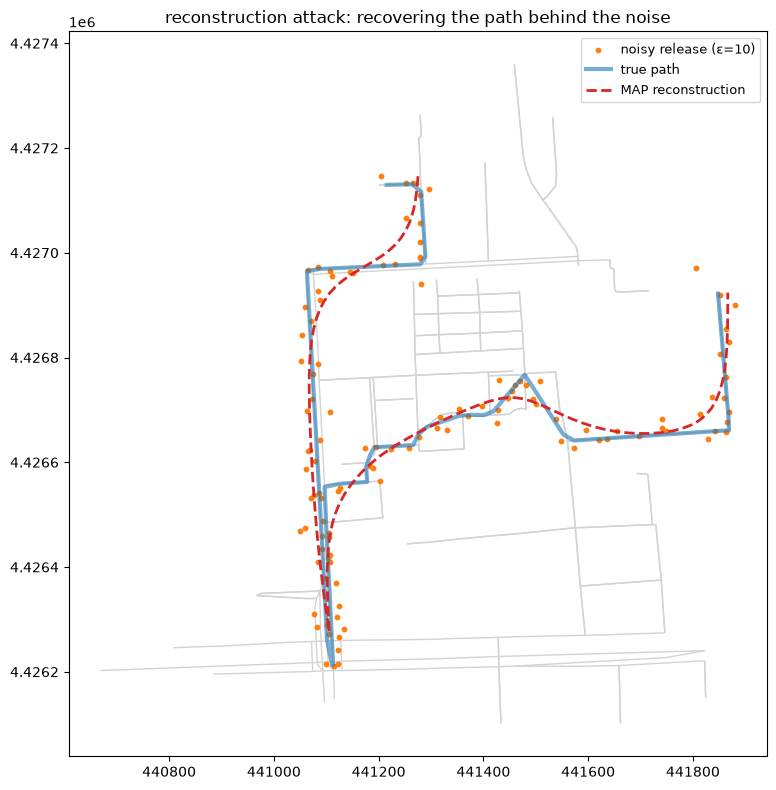

In [25]:
noisy, result = keep[10.0]
rec = result.predictions[1]
fig, ax = plt.subplots(figsize=(8, 8))
tx = [p[0] for p in rec.truth]; ty = [p[1] for p in rec.truth]
pad = 60
base_map(ax, edges=NET.edges.cx[min(tx) - pad : max(tx) + pad, min(ty) - pad : max(ty) + pad])
ax.scatter([p[0] for p in noisy[1]], [p[1] for p in noisy[1]], s=10, color="tab:orange",
           zorder=2, label="noisy release (\u03b5=10)")
ax.plot(tx, ty, "-", color="tab:blue", lw=3, alpha=0.6, zorder=3, label="true path")
ex = [p[0] for p in rec.estimate]; ey = [p[1] for p in rec.estimate]
ax.plot(ex, ey, "--", color="tab:red", lw=2, zorder=4, label="MAP reconstruction")
ax.set_title("reconstruction attack: recovering the path behind the noise")
ax.legend(fontsize=9)
plt.tight_layout()

### 13d. POI inference — where do you live and work?

Stay-point clustering finds places a user lingers; night-hour stays vote for
*home*, day-hour stays for *work*. The road fixtures are all daytime trips, so —
exactly like the attack's own tests — we build three users with purpose-made
night/day dwells, then watch the home/work estimate degrade as geo-ind noise
grows. `home_localised` is the share of users pinned within 200 m of the truth.

In [26]:
from trajguard.attacks.attribute import PoiInferenceAttack, attribute_report
from trajguard.datamodel import CleanTrajectory

BEIJING_TZ = timezone(timedelta(hours=8))

def dwell(traj_id, user, loc, day, hour):
    start = datetime(2008, 11, day, hour, 0, tzinfo=BEIJING_TZ).timestamp()
    pts = tuple((loc[0], loc[1], start + i * 60.0) for i in range(8))
    return CleanTrajectory(traj_id=traj_id, user_id=user, points=pts,
                           bbox=(loc[1], loc[0], loc[1], loc[0]),
                           duration_s=420.0, length_m=0.0, mean_speed=0.0,
                           cleaning_flags=(), split=None)

HOMES = {"A": ((39.900, 116.400), (39.920, 116.420)),
         "B": ((39.950, 116.300), (39.970, 116.330)),
         "C": ((39.850, 116.500), (39.870, 116.470))}
poi_raw = [t for u, (home, work) in HOMES.items()
           for t in (dwell(f"{u}-home", u, home, 1, 2), dwell(f"{u}-work", u, work, 1, 12))]

def protect(trajs, eps):
    mech = GeoIndistinguishability(epsilon=eps, unit_m=100.0, seed=SEED)
    return [replace(t, points=tuple((float(a), float(b), float(c)) for a, b, c in
                                    mech.apply(TrajectoryView(clean=t)).payload))
            for t in trajs]

poi = PoiInferenceAttack(dwell_s=120.0, radius_m=300.0)
rows = []
for label, target in [("raw (sanity)", poi_raw)] + [
        (f"geo-ind \u03b5={e:g}", protect(poi_raw, e)) for e in (10.0, 1.0, 0.1)]:
    rep = attribute_report(poi.run(target, poi_raw))
    rows.append({"arm": label,
                 "home error (m)": round(rep["home_error_m"][0], 1),
                 "work error (m)": round(rep["work_error_m"][0], 1),
                 "home localised \u2264200 m": f"{rep['home_localised'][0]:.0%}",
                 "work localised \u2264200 m": f"{rep['work_localised'][0]:.0%}"})
pd.DataFrame(rows)

,arm,home error (m),work error (m),home localised ≤200 m,work localised ≤200 m
0,raw (sanity),0.0,0.0,100%,100%
1,geo-ind ε=10,7.8,5.0,100%,100%
2,geo-ind ε=1,128.6,97.5,100%,100%
3,geo-ind ε=0.1,NaN,NaN,0%,0%


## 14. Utility — what the protection costs

Privacy numbers only mean something next to **utility damage**. Two paired metrics
compare the raw pool against each released (noisy) pool: the Jensen–Shannon
divergence between cell-visit distributions (0 = identical spatial behaviour) and
the Wasserstein-1 error between trip-length distributions (in metres). This is the
other axis of every privacy-vs-utility trade-off plot.

In [27]:
from trajguard.evaluation.utility import cell_js_divergence, length_dist_error

raw_release = [clean_by_id[m.traj_id] for m in matched]
UGRID = Grid(bbox=GRID.bbox, n_rows=10, n_cols=10)
rows = []
for label, _ in ARMS:
    noisy = noisy_releases[label]  # full release, including re-match casualties
    jsd = cell_js_divergence(raw_release, noisy, grid=UGRID, n_bootstrap=200, ci=0.95,
                             rng=np.random.default_rng(3))
    w1 = length_dist_error(raw_release, noisy, grid=UGRID, n_bootstrap=200, ci=0.95,
                           rng=np.random.default_rng(3))
    rows.append({"arm": label,
                 "cell JS divergence (bits)": f"{jsd[0]:.3f} [{jsd[1]:.3f}, {jsd[2]:.3f}]",
                 "length error W1 (m)": f"{w1[0]:.0f} [{w1[1]:.0f}, {w1[2]:.0f}]"})
pd.DataFrame(rows)

,arm,cell JS divergence (bits),length error W1 (m)
0,ε=0.1 (noise ≈2 km),"0.773 [0.738, 0.896]","174203 [114470, 254208]"
1,ε=1.0 (noise ≈200 m),"0.258 [0.262, 0.354]","16103 [10570, 23563]"
2,ε=10.0 (noise ≈20 m),"0.016 [0.007, 0.044]","778 [497, 1169]"
3,"ε=10.0, unit 25 m (noise ≈5 m)","0.003 [0.001, 0.010]","53 [32, 84]"


## 15. The full experiment, one config at a time

Everything above, orchestrated: a YAML config describes map, dataset, cleaning,
matching, split, mechanisms, attacks, and metrics; `run_experiment` executes the
whole pipeline with caching and writes `metrics.csv`, `matrix.csv`, `run.json`
(and `tradeoff.png` when requested). We run it here against the fixtures inside a
**temporary directory** — the repo stays untouched. On real data you would run
`uv run trajguard run config/experiments/<name>.yaml` instead (`docs/RUNNING.md`
§§5–7).

In [28]:
import yaml
from trajguard.experiments.orchestrator import run as run_config

TMP = Path(tempfile.mkdtemp(prefix="trajguard_walkthrough_"))
shutil.copytree(FIXTURES / "maps" / "beijing_fixture", TMP / "maps" / "beijing")

def experiment_config(exp_id, mechanisms, extra_metrics=None, plots=()):
    cfg = {
        "experiment": {"id": exp_id, "seed": SEED,
                       "output_dir": str(TMP / "results" / exp_id),
                       "cache_dir": str(TMP / "cache"),
                       "protected_dir": str(TMP / "protected")},
        "map": {"source": "osm", "region": "beijing",
                "bbox": [116.30, 39.98, 116.32, 39.995], "crs": "EPSG:32650",
                "dir": str(TMP / "maps")},
        "dataset": {"id": "geolife", "path": str(FIXTURES / "geolife_onroad"),
                    "native_region": "beijing"},
        "cleaning": {"max_speed_kmh": 200, "min_points": 20, "min_length_m": 500, "resample_s": 5},
        "map_matching": {"matcher": "leuven", "min_match_score": 0.6},
        "split": {"scheme": "by_user",
                  "fractions": {"train": 0.5, "test": 0.2, "shadow": 0.2, "attack": 0.1}},
        "privacy_mechanisms": mechanisms,
        "attacks": [{"type": "reidentification",
                     "attacker": {"known_points": [3, 5], "distance": "dtw"},
                     "target_scope": ["raw", "protected"]}],
        "metrics": {"privacy": ["top1_acc", "topk_acc", "linkage_rate"], "top_k": 5,
                    "bootstrap": {"n": 200, "ci": 0.95}, **(extra_metrics or {})},
        "reporting": {"export": ["csv"], "plots": list(plots)},
    }
    path = TMP / f"{exp_id}.yaml"
    path.write_text(yaml.safe_dump(cfg))
    return path

baseline_values = run_config(experiment_config("walkthrough_baseline", [{"id": "none"}]))
pd.DataFrame([{"result_id": v.result_id, "metric": v.name, "value": round(v.value, 3),
               "95% CI": f"[{v.ci_low:.2f}, {v.ci_high:.2f}]"} for v in baseline_values])

,result_id,metric,value,95% CI
0,reidentification:raw:k3,top1_acc,0.25,"[0.00, 0.50]"
1,reidentification:raw:k3,top5_acc,1.00,"[1.00, 1.00]"
2,reidentification:raw:k3,linkage_rate,0.25,"[0.00, 0.50]"
3,reidentification:raw:k5,top1_acc,0.25,"[0.00, 0.50]"
4,reidentification:raw:k5,top5_acc,1.00,"[1.00, 1.00]"
5,reidentification:raw:k5,linkage_rate,0.25,"[0.00, 0.50]"
6,reidentification:protected:none:k3,top1_acc,0.25,"[0.00, 0.50]"
7,reidentification:protected:none:k3,top5_acc,1.00,"[1.00, 1.00]"
8,reidentification:protected:none:k3,linkage_rate,0.25,"[0.00, 0.50]"
9,reidentification:protected:none:k5,top1_acc,0.25,"[0.00, 0.50]"


In [29]:
geoind_values = run_config(experiment_config(
    "walkthrough_geoind",
    [{"id": "none"},
     {"id": "geo_indistinguishability", "params": {"epsilon": [1.0, 10.0], "unit_m": 25.0}}],
    extra_metrics={"utility": ["cell_js_divergence", "length_dist_error"],
                   "utility_grid": {"n_rows": 10, "n_cols": 10}},
    plots=("tradeoff",),
))
run_record = json.loads((TMP / "results" / "walkthrough_geoind" / "run.json").read_text())
print(f"pipeline: {run_record['n_matched']} matched, {run_record['n_dropped']} dropped, "
      f"split counts {run_record['split_counts']}")
pd.DataFrame.from_dict(run_record["arms"], orient="index")

pipeline: 8 matched, 0 dropped, split counts {'test': 4, 'train': 4}


,n_pool,n_gallery_users,n_probes,n_rematch_dropped,spent_budget
raw,8,2,8,0,NaN
protected:none,8,2,8,0,NaN
"protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0",0,0,8,8,504.0
"protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0",8,2,8,0,5040.0


In [30]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.imshow(plt.imread(TMP / "results" / "walkthrough_geoind" / "tradeoff.png"))
ax.set_axis_off()
ax.set_title("tradeoff.png as written by the run: attack success vs utility damage per arm")
plt.tight_layout()

The orchestrator also **refuses impossible experiments**: the map and the dataset
must cover the same city, otherwise map matching would silently produce garbage.
Watch the guard fire:

In [31]:
from trajguard.experiments.orchestrator import ConsistencyError

bad = yaml.safe_load((TMP / "walkthrough_baseline.yaml").read_text())
bad["experiment"]["id"] = "walkthrough_bad_region"
bad["map"]["region"] = "ljubljana"
bad["dataset"]["native_region"] = ""
bad_path = TMP / "bad.yaml"
bad_path.write_text(yaml.safe_dump(bad))
try:
    run_config(bad_path)
except ConsistencyError as err:
    print(f"\u26a0\ufe0f  rejected as designed: {err}")

⚠️  rejected as designed: map.region 'ljubljana' != dataset 'geolife' native_region 'beijing'; refusing to run (design T1)


## 16. The risk report

`generate_report` aggregates every `run.json` under a results directory into a
Markdown risk report (plus long-form CSV/Parquet tables, a risk-matrix CSV, and
trade-off plots). On real data this is `uv run trajguard report`. Below, the
report generated from the two runs above is rendered inline (its image links
point at files in the temp report directory).

In [32]:
from IPython.display import Markdown, display
from trajguard.reporting.report import generate_report

report_path = generate_report(TMP / "results", TMP / "reports")
print("files written:", sorted(p.name for p in (TMP / "reports").iterdir()), "\n")
display(Markdown(report_path.read_text()))

files written: ['metrics_long.csv', 'metrics_long.parquet', 'report.md', 'risk_matrix.csv', 'tradeoff_walkthrough_geoind.png'] 



# trajguard risk report

Generated 2026-07-12 14:26 UTC from `/tmp/trajguard_walkthrough_7se7vrfq/results` — 2 experiment runs.

## Runs

| experiment | pipeline | commit | seed | created | matched | dropped | split | bootstrap | runtime |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| walkthrough_baseline | `7a70364f4c51d605` | `6df22fbc70` | 42 | 2026-07-12T14:26:33.262022+00:00 | 8 | 0 | train=4, test=4 | n=200, 95% CI | 1.4 s |
| walkthrough_geoind | `7a70364f4c51d605` | `6df22fbc70` | 42 | 2026-07-12T14:26:34.892936+00:00 | 8 | 0 | train=4, test=4 | n=200, 95% CI | 1.6 s |

## Risk matrix

One row per released arm, one column per attack family. Each cell is the family's
headline metric at the attacker's largest `known_points` (`@k`), with its bootstrap CI.
Higher means more risk, except metrics named `*_m` (errors in metres), where a lower
error means a more successful attack.

| target | reidentification — top1_acc |
| --- | --- |
| raw | 0.250 [0.000, 0.503] @k=5 |
| protected:none | 0.250 [0.000, 0.503] @k=5 |
| protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0 | 0.000 [0.000, 0.000] @k=5 |
| protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0 | 0.250 [0.000, 0.503] @k=5 |

## Attack detail

### reidentification — `walkthrough_baseline`

| target | k | top1_acc | linkage_rate | top5_acc |
| --- | --- | --- | --- | --- |
| raw | 3 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| raw | 5 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:none | 3 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:none | 5 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |

### reidentification — `walkthrough_geoind`

| target | k | top1_acc | linkage_rate | top5_acc |
| --- | --- | --- | --- | --- |
| raw | 3 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| raw | 5 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:none | 3 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:none | 5 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0 | 3 | 0.000 [0.000, 0.000] | 0.000 [0.000, 0.000] | 0.000 [0.000, 0.000] |
| protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0 | 5 | 0.000 [0.000, 0.000] | 0.000 [0.000, 0.000] | 0.000 [0.000, 0.000] |
| protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0 | 3 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |
| protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0 | 5 | 0.250 [0.000, 0.503] | 0.250 [0.000, 0.500] | 1.000 [1.000, 1.000] |

## Utility (protected release vs raw)

### `walkthrough_geoind`

| target | cell_js_divergence | length_dist_error |
| --- | --- | --- |
| protected:none | 0.000 [0.000, 0.000] | 0.000 [0.000, 0.000] |
| protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0 | 0.068 [0.061, 0.102] | 3105.520 [1822.831, 4644.356] |
| protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0 | 0.003 [0.002, 0.008] | 53.353 [29.658, 86.156] |

## Arm health

Pool and probe sizes per arm; `re-match dropped` counts released trajectories that no
longer matched the road network (protection by destroying the release).

| experiment | target | pool | gallery users | probes | re-match dropped | spent budget |
| --- | --- | --- | --- | --- | --- | --- |
| walkthrough_baseline | raw | 8 | 2 | 8 | 0 | – |
| walkthrough_baseline | protected:none | 8 | 2 | 8 | 0 | – |
| walkthrough_geoind | raw | 8 | 2 | 8 | 0 | – |
| walkthrough_geoind | protected:none | 8 | 2 | 8 | 0 | – |
| walkthrough_geoind | protected:geo_indistinguishability:epsilon=1.0,unit_m=25.0 | 0 | 0 | 8 | 8 | 504.000 |
| walkthrough_geoind | protected:geo_indistinguishability:epsilon=10.0,unit_m=25.0 | 8 | 2 | 8 | 0 | 5040.000 |

## Privacy–utility tradeoff

![privacy–utility tradeoff for walkthrough_geoind](tradeoff_walkthrough_geoind.png)

## Exported files

- `metrics_long.csv`
- `metrics_long.parquet`
- `risk_matrix.csv`


## 17. RN-LDP-Synth evidence sweep

The standing evaluation for the doctoral mechanism (CLI:
`uv run python -m trajguard.experiments.rnldp_eval`): for each ε it fits
RN-LDP-Synth on half a seeded population, generates, and reports membership-
inference exposure (AUC, TPR at low false-positive rates) plus utility (cell JSD,
length W1) with a non-private Markov ceiling for reference. Expect ≈0.5 AUC (no
better than guessing) at moderate ε and total exposure at the deliberately absurd
ε=80. Shrunk here (6 shadows, 12 devices) to keep the cell fast; fixture-scale
numbers are evidence, not results.

In [33]:
from trajguard.experiments.rnldp_eval import run_eval

sweep = run_eval(NET, epsilons=[0.5, 2.0, 8.0, 80.0], n_shadow=6, n_pop=12, seed=20260706)
pd.DataFrame([
    {"arm": arm,
     "MIA AUC": round(r["mia"]["auc"], 3),
     "TPR@FPR=0.01": round(r["mia"]["tpr@fpr=0.01"], 2),
     "TPR@FPR=0.1": round(r["mia"]["tpr@fpr=0.1"], 2),
     "cell JSD (bits)": f"{r['utility']['cell_jsd']:.3f}",
     "length W1 (m)": f"{r['utility']['length_w1_m']:.0f}"}
    for arm, r in sweep["arms"].items()
])

,arm,MIA AUC,TPR@FPR=0.01,TPR@FPR=0.1,cell JSD (bits),length W1 (m)
0,rn_ldp_synth@eps=0.5,0.528,0.33,0.33,0.433,1043
1,rn_ldp_synth@eps=2,0.500,0.33,0.33,0.431,1027
2,rn_ldp_synth@eps=8,0.556,0.33,0.33,0.442,963
3,rn_ldp_synth@eps=80,0.667,0.67,0.67,0.307,503
4,markov (non-private ceiling),0.611,0.33,0.33,0.037,1206


## 18. Where the edges of the implementation are

Demonstrated as ⚠️ above and listed here for one-glance completeness — planned in
the design but **not implemented yet**:

- **Loaders**: T-Drive, Porto (interface exists; only Geolife is real).
- **Matcher**: `fmm` (production matcher; `leuven` is the working one).
- **Mechanisms** (design §7): spatial rounding, temporal downsampling,
  Gaussian/Laplace naive noise, point-LDP, SquareWave, segment perturbation,
  k-anonymity, combined mechanisms.
- **Generators**: DPT, AdaTrace (central DP); Diff-RNTraj, ControlTraj (diffusion).
- **Views**: `as_graph_path()`, `as_poi_visits()` (raise `NotImplementedError`).
- **Orchestrator**: only reidentification runs from YAML; membership inference,
  reconstruction, and POI inference run via their Python APIs (section 13);
  synthetic-target arms in configs are rejected on purpose.
- **Infrastructure** (deliberately deferred): PostGIS, MLflow tracking, federated
  approaches, the full attribute-inference classifier.

To reproduce any stage on **real data**: `docs/RUNNING.md` (setup §§0–2,
experiments §§5–7, troubleshooting §11). Design rationale:
`docs/Tehnicna_zasnova_eksperimentalno_okolje.md`; architecture quick reference:
`docs/ARCHITECTURE.md`; RN-LDP-Synth: `docs/RN_LDP_SYNTH_DESIGN.md`.